<a href="https://colab.research.google.com/github/janzika/CarbonAirTime/blob/main/AnalysisforZikaandChurch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
## install packages and import libraries
import pandas as pd
import numpy as np
# Plotting
import matplotlib.pyplot as plt
from google.colab import files
from google.colab import drive
plt.rcParams['figure.figsize'] = [6,6]
# plot figures in Colaboratory notebook
%matplotlib inline

In [20]:
#%%bash
# Mounting requires a special 'bash' command
!git clone https://github.com/janzika/CarbonAirTime.git

fatal: destination path 'CarbonAirTime' already exists and is not an empty directory.


In [21]:

#load from github repo.
df = pd.read_csv('./CarbonAirTime/AirTimeAllData_v15.csv')

<>:47: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3873/3939253532.py:47: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('Simulated SAT change due to non-CO$_2$ forcing ($^{\circ}$C)')


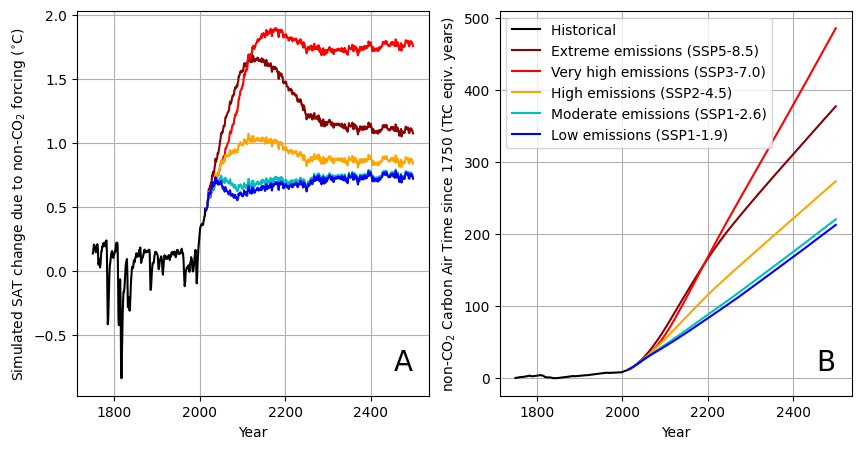

In [22]:
SSPs = ['SSP119','SSP126','SSP245','SSP370','SSP585']
clr = ['b','c','orange','red','darkred']
lbl = ['Low emissions (SSP1-1.9)',
       'Moderate emissions (SSP1-2.6)',\
        'High emissions (SSP2-4.5)',\
        'Very high emissions (SSP3-7.0)',\
        'Extreme emissions (SSP5-8.5)']
yrSTR=1750
yrBRCH = 2015
yrEND=2500

CCR = 1.65
fig, [ax2,ax3] = plt.subplots(1,2,figsize = [10,5])

HistAirTimeCO2 = np.cumsum(\
        df['Historical cumilative CO_2 emissions (TtC)']).values

HistAirTimenonCO2 = np.cumsum(\
        df['Historical non-CO_2 forcing (TtC; CO_2 equiv.)'])

HistAirTimenonCO2_1800base = np.cumsum(\
        df['Historical non-CO_2 forcing (TtC; CO_2 equiv.)']-np.mean(\
        df['Historical non-CO_2 forcing (TtC; CO_2 equiv.)'][df.Year==1850]))

ax2.plot(df['Year'],\
        CCR*df['Historical non-CO_2 forcing (TtC; CO_2 equiv.)']\
        ,color='k',label ='Historical ')

ax3.plot(df['Year'],\
        np.cumsum(df['Historical non-CO_2 forcing (TtC; CO_2 equiv.)']).values\
             ,color='k',label ='Historical ')

for ssp in range(len(SSPs)-1,-1,-1):

    ax2.plot(df.loc[(df.Year>=yrSTR) & (df.Year<yrEND),'Year'],\
        CCR*df.loc[(df.Year>=yrSTR) & (df.Year<yrEND),SSPs[ssp]+' non-CO_2 forcing (TtC; CO_2 equiv.)']\
        ,color=clr[ssp],label =lbl[ssp])
    AirTimenonCO2 = np.cumsum(\
        df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),SSPs[ssp]+' non-CO_2 forcing (TtC; CO_2 equiv.)']).values\
        +HistAirTimenonCO2[(df.Year==(yrBRCH-1))].values
    ax3.plot(df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'Year'],\
        AirTimenonCO2,color=clr[ssp],label =lbl[ssp])

ax3.legend()

ax2.set_xlabel('Year')
ax2.set_ylabel('Simulated SAT change due to non-CO$_2$ forcing ($^{\circ}$C)')

ax3.set_xlabel('Year')
ax3.set_ylabel('non-CO$_2$ Carbon Air Time since '+str(yrSTR)+' (TtC eqiv. years)')

ax2.text(0.90, 0.05, "A",
        transform=ax2.transAxes,  # Use axes-relative coordinates
        horizontalalignment='left',
        verticalalignment='bottom',
        fontsize=20,
        color='k')

ax3.text(0.90, 0.05, "B",
        transform=ax3.transAxes,  # Use axes-relative coordinates
        horizontalalignment='left',
        verticalalignment='bottom',
        fontsize=20,
        color='k')

ax2.grid()
ax3.grid()
#ax2.axis([1850,2000,-0.3,0.3])
#ax3.axis([2010,2020,0,20])

In [23]:

TotAirTime19952014ref = HistAirTimeCO2+HistAirTimenonCO2\
  -np.mean((HistAirTimeCO2+HistAirTimenonCO2)[(df.Year>1994) & (df.Year<2015)])
CO2AirTime19952014ref = HistAirTimeCO2\
  -np.mean((HistAirTimeCO2)[(df.Year>1994) & (df.Year<2015)])
nonCO2AirTime19952014ref = HistAirTimenonCO2\
  -np.mean((HistAirTimenonCO2)[(df.Year>1994) & (df.Year<2015)])
nonCO2AirTime19952014ref_1800base = HistAirTimenonCO2_1800base\
  -np.mean((HistAirTimenonCO2_1800base)[(df.Year>1994) & (df.Year<2015)])


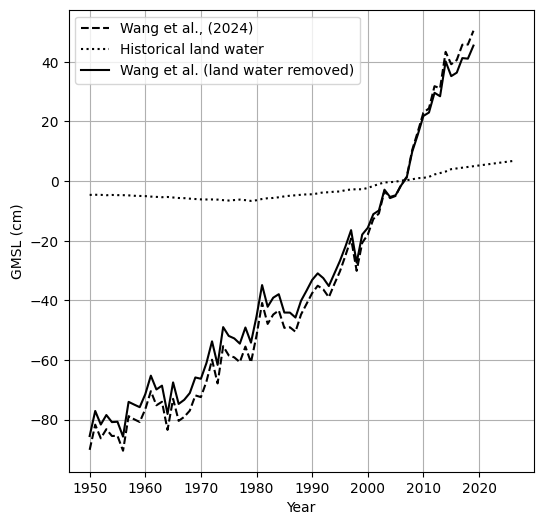

In [24]:
yrSTR=1950
lastLWyr = 2016
lastALTyr = 2026
df.loc[(df.Year>lastLWyr) & (df.Year<=lastALTyr),'Historical land water (mm)']  = \
 df.loc[df.Year==2016,'Historical land water (mm)'].values+\
 np.arange(1,lastALTyr-lastLWyr+1)*\
 (df.loc[df.Year==2016,'Historical land water (mm)'].values-\
  df.loc[df.Year==2015,'Historical land water (mm)'].values)

plt.rcParams['figure.figsize'] = [6,6]
plt.plot(df.loc[df.Year>=yrSTR,'Year'],\
        df.loc[df.Year>=yrSTR,'Wang et al., 2024 (mm)'],\
         label = 'Wang et al., (2024)',linestyle ='--',color='k')

plt.plot(df.loc[df.Year>=yrSTR,'Year'],\
        df.loc[df.Year>=yrSTR,'Historical land water (mm)'],\
         label = 'Historical land water',linestyle =':',color='k')

plt.plot(df.loc[df.Year>=yrSTR,'Year'],\
        df.loc[df.Year>=yrSTR,'Wang et al., 2024 (mm)']\
         -df.loc[df.Year>=yrSTR,'Historical land water (mm)'],\
         label = 'Wang et al. (land water removed)',linestyle ='-',color='k')

plt.grid()
plt.xlabel('Year')
plt.ylabel('GMSL (cm)')
plt.legend()

In [25]:
#Altimiter fit
yr1=1993
yr2=2024
X = TotAirTime19952014ref[(df.Year>=yr1) & (df.Year<yr2)]
Y = (df.loc[(df.Year>=yr1) & (df.Year<yr2),'Altimeter (mm)']-\
        df.loc[(df.Year>=yr1) & (df.Year<yr2),'Historical land water (mm)']\
        )/10
deg = 1
fit = np.polyfit(X,Y,deg,rcond=None, full=True, w=None, cov=False)
b = fit[0][0];
a = fit[0][1];
Se = fit[1]/(len(X)-2)
sumsqtot = np.sum((X.values-np.mean(X.values))**2)
sig_b = np.sqrt(Se/sumsqtot)
Syhat = Se*(1+1/len(X)+(X-np.mean(X))**2/sumsqtot)

n = len(Y)
dof = n-(deg+1)
y_pred_train = np.polyval(fit[0], X)
residuals = Y - y_pred_train
sigma2_res = np.sum(residuals**2) / dof
sig_a = np.sqrt(sigma2_res*(1+1/n))
[b-sig_b,b+sig_b],sig_a,sig_b

([array([0.44261831]), array([0.45975492])],
 np.float64(0.2586699266367173),
 array([0.0085683]))

In [26]:
fitOBSs = np.zeros((5,1))
SLmutualyrs = [1993,2010]
yr1=SLmutualyrs[0]
yr2=SLmutualyrs[1]

SLROBSset = ['Hay et al.,  2015 (mm)','Dangendorf et al., 2019 (mm)',\
              'Frederikse et al., 2020 (mm)','Wang et al., 2024 (mm)','Altimeter (mm)']
GMSLobs=[]
CATobs=[]
for obsx in range(0,len(SLROBSset)):
    obsx
    GMSLobs=np.concat((GMSLobs,\
        ((df.loc[(df.Year>=yr1) & (df.Year<=yr2),SLROBSset[obsx]]).values - \
         (df.loc[(df.Year>=yr1) & (df.Year<=yr2),'Historical land water (mm)']))/10))
    CATobs=np.concat((CATobs,TotAirTime19952014ref[(df.Year>=yr1) & (df.Year<=yr2)]))

deg=1
fitTG = np.polyfit(CATobs,\
                  GMSLobs,\
                  deg,rcond=None, full=True, w=None, cov=False)
fitTG

bTG = fitTG[0][0];
aTG = fitTG[0][1];
SeTG = fitTG[1]/(len(GMSLobs)-2)
sumsqtotTG = np.sum((GMSLobs-np.mean(GMSLobs))**2)
sig_bTG = np.sqrt(SeTG/sumsqtotTG)
SyhatTG = SeTG*(1+1/len(GMSLobs)+(GMSLobs-np.mean(GMSLobs))**2/sumsqtotTG)

n = len(CATobs)
dof = n-(deg+1)
y_pred_trainTG = np.polyval(fitTG[0], CATobs)
residualsTG = GMSLobs - y_pred_trainTG
sigma2_resTG = np.sum(residualsTG**2) / dof
sig_aTG = np.sqrt(sigma2_resTG*(1+1/n))
[bTG-sig_bTG,bTG+sig_bTG],sig_aTG,sig_bTG


([array([0.49279563]), array([0.55150927])],
 np.float64(0.37997050703874574),
 array([0.02935682]))

In [27]:
yrBRCH=2015
yrEND=2100

SL2 = a+b*X.values[yrBRCH-yr1]
SL2_upper = a+sig_a+(b+sig_b)*X.values[yrBRCH-yr1]
SL2_lower = a-sig_a+(b-sig_b)*X.values[yrBRCH-yr1]

fitSSPs = np.zeros((5,1))
fitSSPs_low = np.zeros((5,1))
fitSSPs_high = np.zeros((5,1))
fitpower = np.zeros((5,2))
fit2ndorderSSPs = np.zeros((5,2))
fit2ndbackwards = np.zeros((5,3))
for ssp in range(len(SSPs)-1,-1,-1):
    AirTime = np.cumsum(\
        df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),SSPs[ssp]+' cumilative CO_2 emissions (TtC)']+\
        df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),SSPs[ssp]+' non-CO_2 forcing (TtC; CO_2 equiv.)']).values\
        +TotAirTime19952014ref[(df.Year==yrBRCH-1)].values
    GMSL=\
        (df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'Projected GMSL '+SSPs[ssp]+' (mm)']-\
        df.loc[df.Year==yrBRCH,'Projected GMSL '+SSPs[ssp]+' (mm)'].values+\
        SL2*10)/10
    GMSL_low = (df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'Projected GMSL '+SSPs[ssp]+' Lower (mm)']-\
        df.loc[df.Year==yrBRCH,'Projected GMSL '+SSPs[ssp]+' Lower (mm)'].values+\
        SL2*10)/10
    GMSL_high = (df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'Projected GMSL '+SSPs[ssp]+' Upper (mm)']-\
        df.loc[df.Year==yrBRCH,'Projected GMSL '+SSPs[ssp]+' Upper (mm)'].values+\
        SL2*10)/10
    X1 = np.vstack([AirTime**(i+1) for i in range(1)]).T[:, ::-1]
    fitSSPs[ssp] = np.polyfit(AirTime,GMSL,1,rcond=None, full=True, w=None, cov=False)[0][0]
    fitSSPs_low[ssp] = np.polyfit(AirTime,GMSL_low,1,rcond=None, full=True, w=None, cov=False)[0][0]
    fitSSPs_high[ssp] = np.polyfit(AirTime,GMSL_high,1,rcond=None, full=True, w=None, cov=False)[0][0]
    fitpower[ssp,:] = np.polyfit(np.log(AirTime),np.log(GMSL),1,rcond=None, full=True, w=None, cov=False)[0][0:2]
    X2 = np.vstack([AirTime**(i+1) for i in range(2)]).T[:, ::-1]
    fit2ndorderSSPs[ssp,:], residuals, rank, s = np.linalg.lstsq(X2, GMSL, rcond=None)
    fit2ndbackwards[ssp,:] = np.polyfit(GMSL,AirTime,2,rcond=None, full=True, w=None, cov=False)[0][0:3]
fitSSPs, fitSSPs_low, fitSSPs_high

(array([[0.48752991],
        [0.49031247],
        [0.49702955],
        [0.50848969],
        [0.49191181]]),
 array([[0.29429965],
        [0.30992646],
        [0.33414034],
        [0.35786283],
        [0.34871576]]),
 array([[0.66448498],
        [0.65164313],
        [0.64299044],
        [0.6401159 ],
        [0.61557122]]))

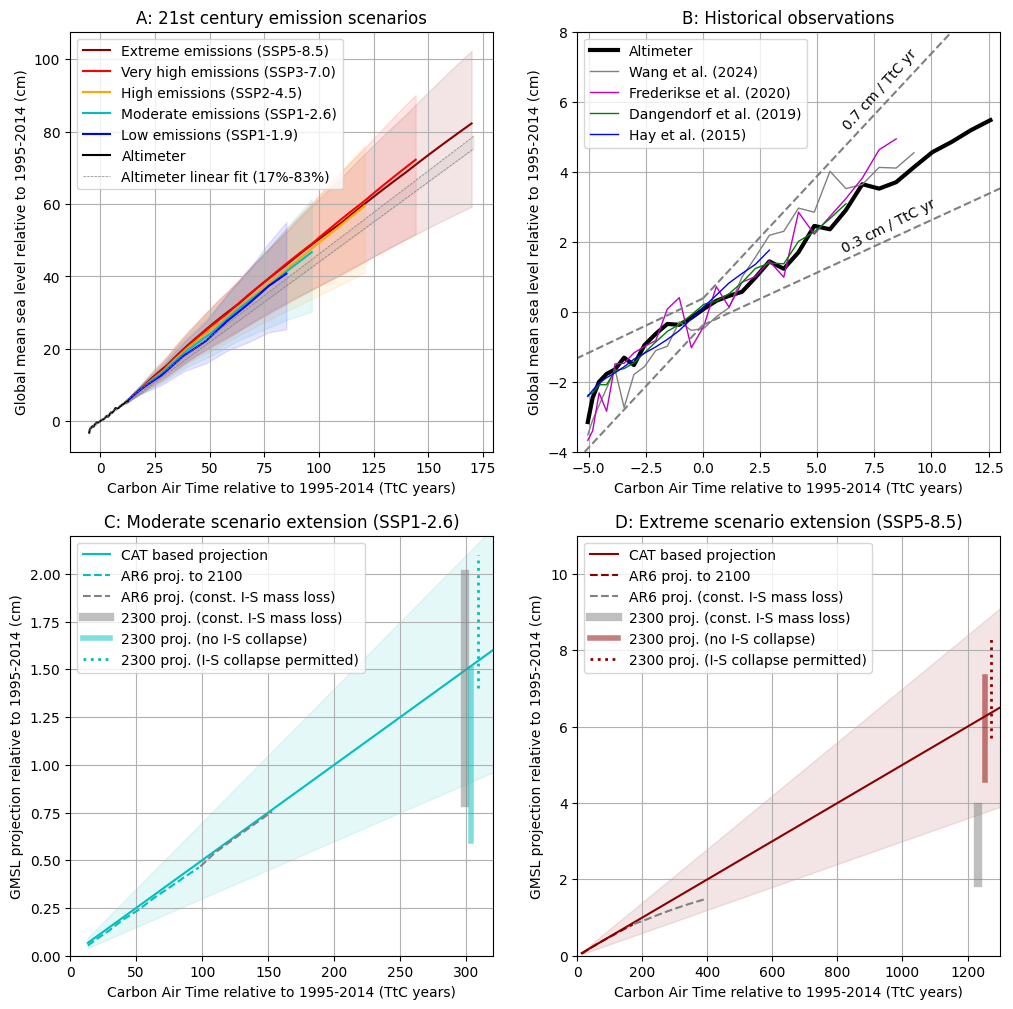

In [28]:
fig, ax = plt.subplots(2,2,figsize = [12,12])

CATSLratio = 0.5
CATSLratio_low = 0.3
CATSLratio_high = 0.7

SLmutualyrs = [1993,2010]
yr1=1993
yrBRCH=2023
yr2=2024

noSTDs = 1#noSTDs

SL2 = a+b*X.values[yrBRCH-yr1-1]
SL2_upper = a+noSTDs*sig_a+(b+noSTDs*sig_b)*X.values[yrBRCH-yr1-1]
SL2_lower = a-noSTDs*sig_a+(b-noSTDs*sig_b)*X.values[yrBRCH-yr1-1]

SLRsubset = ['Hay et al.,  2015 (mm)','Dangendorf et al., 2019 (mm)',\
              'Frederikse et al., 2020 (mm)','Wang et al., 2024 (mm)',\
             'Altimeter (mm)']

SLlbl = ['Hay et al. (2015)','Dangendorf et al. (2019)',\
              'Frederikse et al. (2020)','Wang et al. (2024)',\
             'Altimeter']
SLclr = ['b','g','m','gray','k']
widths = [1,1,1,1,3]

for cx in range(4,-1,-1):
  ax[0][1].plot(\
           TotAirTime19952014ref[df.Year>=yr1],\
        (df.loc[df.Year>=yr1,SLRsubset[cx]] -\
        df.loc[df.Year>=yr1,'Historical land water (mm)']).values/10,\
           label=SLlbl[cx],linewidth=widths[cx],color=SLclr[cx])

zoten=np.array([0,15]);
ax[0][1].plot(zoten,sig_aTG+(zoten*CATSLratio_high),'--',color='grey')
ax[0][1].text(6, 5.2, str(CATSLratio_high)+' cm / TtC yr', rotation=np.tan(0.7)*180/np.pi)

ax[0][1].plot(zoten,-sig_aTG+(zoten*CATSLratio_low),'--',color='grey')
ax[0][1].text(6, 1.7, str(CATSLratio_low)+' cm / TtC yr', rotation=np.tan(0.44)*180/np.pi)

ax[0][1].plot(-zoten,-sig_aTG-(zoten*0.7),'--',color='grey')
ax[0][1].plot(-zoten,sig_aTG-(zoten*0.31),'--',color='grey')

ax[0][1].legend()
ax[0][1].grid()
ax[0][1].set_ylabel('Global mean sea level relative to 1995-2014 (cm)')
ax[0][1].set_xlabel('Carbon Air Time relative to 1995-2014 (TtC years)')

for ssp in range(len(SSPs)-1,-1,-1):
    AirTime = np.insert(np.cumsum(\
        df.loc[(df.Year>yrBRCH) & (df.Year<yrEND),SSPs[ssp]+' cumilative CO_2 emissions (TtC)']+\
        df.loc[(df.Year>yrBRCH) & (df.Year<yrEND),SSPs[ssp]+' non-CO_2 forcing (TtC; CO_2 equiv.)']).values+\
             TotAirTime19952014ref[(df.Year==yrBRCH-1)].values,0,\
                        TotAirTime19952014ref[(df.Year==yrBRCH-1)].values)
    ax[0][0].plot(AirTime,\
        (df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'Projected GMSL '+SSPs[ssp]+' (mm)']-\
          df.loc[df.Year==yrBRCH,'Projected GMSL '+SSPs[ssp]+' (mm)'].values+\
             SL2*10)/10,color=clr[ssp],label =lbl[ssp])

    ax[0][0].fill_between(AirTime,\
        (df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'Projected GMSL '+SSPs[ssp]+' Lower (mm)']-\
         df.loc[df.Year==yrBRCH,'Projected GMSL '+SSPs[ssp]+' Lower (mm)'].values+\
             SL2_lower*10)/10,\
        (df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'Projected GMSL '+SSPs[ssp]+' Upper (mm)']-\
         df.loc[df.Year==yrBRCH,'Projected GMSL '+SSPs[ssp]+' Upper (mm)'].values+\
             SL2_upper*10)/10,color=clr[ssp],alpha=0.1)

ax[0][0].plot(X,Y,'k',label='Altimeter')

ax[0][0].plot(X,a+noSTDs*np.sqrt(Syhat)+(b+noSTDs*sig_b)*X,\
                 'grey',linewidth=0.5,linestyle ='--')

ax[0][0].plot(X,a-noSTDs*np.sqrt(Syhat)+(b-noSTDs*sig_b)*X,\
                 'grey',linewidth=0.5,linestyle ='--')

X2 = [TotAirTime19952014ref[(df.Year==yrBRCH-1)].values[0],np.sum(\
        df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'SSP585 cumilative CO_2 emissions (TtC)']+\
        df.loc[(df.Year>=yrBRCH) & (df.Year<yrEND),'SSP585 non-CO_2 forcing (TtC; CO_2 equiv.)'])+\
             TotAirTime19952014ref[(df.Year==yrBRCH-1)].values[0]]
ax[0][0].fill_between(X2,SL2_lower+\
                    (b-noSTDs*sig_b)*(np.array(X2)-\
                        TotAirTime19952014ref[(df.Year==yrBRCH-1)].values),\
                    SL2_upper+\
                    (b+noSTDs*sig_b)*(np.array(X2)-\
                        TotAirTime19952014ref[(df.Year==yrBRCH-1)].values),\
                 color='grey',alpha=0.1)

ax[0][0].plot(X2,SL2_lower+\
                    (b-noSTDs*sig_b)*(np.array(X2)-\
                        TotAirTime19952014ref[(df.Year==yrBRCH-1)].values),\
                    'grey',linewidth=0.5,linestyle ='--',\
                    label = 'Altimeter linear fit (17%-83%)')

ax[0][0].plot(X2,SL2_upper+\
                    (b+noSTDs*sig_b)*(np.array(X2)-\
                        TotAirTime19952014ref[(df.Year==yrBRCH-1)].values),\
                    'grey',linewidth=0.5,linestyle ='--')

ax[0][0].legend()
ax[0][0].grid()
ax[0][0].set_ylabel('Global mean sea level relative to 1995-2014 (cm)')
ax[0][0].set_xlabel('Carbon Air Time relative to 1995-2014 (TtC years)')

ax[0][0].set_title('A: 21st century emission scenarios')
ax[0][1].set_title('B: Historical observations')

ax[0][1].axis([-5.5,13,-4,8])

#Post 2100 GMSL
yrEx1=2100
yrEx1p1=2140
yrEx1p2=2190
yrEx2=2250
yrEx3=2500

SSPsubset = [1,4]

EMS = np.zeros(3)
Tthreehundred = np.zeros(2)
SLmax = np.zeros((len(SSPsubset),1))

for ssp in range(len(SSPsubset)-1,-1,-1):
    #Calibrate so total Airtime is same at 2100
    TotalAirTime = \
      TotAirTime19952014ref[df.Year==yr2-1].values+ \
      np.cumsum(df.loc[(df.Year>=yr2) & (df.Year<yrEx3),SSPs[SSPsubset[ssp]]+' cumilative CO_2 emissions (TtC)']+\
      df.loc[(df.Year>=yr2) & (df.Year<yrEx3),SSPs[SSPsubset[ssp]]+' non-CO_2 forcing (TtC; CO_2 equiv.)']\
      ).values

    ax[1][ssp].plot(TotalAirTime,
        TotalAirTime*CATSLratio/100,color=clr[SSPsubset[ssp]],label='CAT based projection')
    ax[1][ssp].plot(TotalAirTime[0:76],\
        (df.loc[(df.Year>=yr2) & (df.Year<yrEND),\
                'Projected GMSL '+SSPs[SSPsubset[ssp]]+' (mm)']-\
          df.loc[df.Year==yr2,'Projected GMSL '+SSPs[SSPsubset[ssp]]+' (mm)'].values+\
             SL2*10)/1000,'--',color=clr[SSPsubset[ssp]],label ='AR6 proj. to 2100')
    ax[1][ssp].plot(TotalAirTime[76:],\
        (df.loc[df.Year>=yrEND,\
                'Projected GMSL '+SSPs[SSPsubset[ssp]]+' (mm)']-\
          df.loc[df.Year==yr2,'Projected GMSL '+SSPs[SSPsubset[ssp]]+' (mm)'].values+\
             SL2*10)/1000,'--',color='grey',label ='AR6 proj. (const. I-S mass loss)')

    ax[1][ssp].fill_between(TotalAirTime,\
        TotalAirTime*CATSLratio_low/100,\
        TotalAirTime*CATSLratio_high/100,color=clr[SSPsubset[ssp]],alpha=0.1)

    ax[1][ssp].grid()
    ax[1][ssp].set_ylabel('GMSL projection relative to 1995-2014 (cm)')
    ax[1][ssp].set_xlabel('Carbon Air Time relative to 1995-2014 (TtC years)')

    Tthreehundred[ssp] = TotalAirTime[2300-yr2]

ax[1][0].axis([0,320,0,2.2])
ax[1][1].axis([0,1300,0,11])

ax[1][0].set_title("C: Moderate scenario extension (SSP1-2.6)")
ax[1][0].plot([Tthreehundred[0]-5,Tthreehundred[0]-5],[0.8,2],'-',color='grey',alpha=0.5,linewidth=6,label='2300 proj. (const. I-S mass loss)')
ax[1][0].plot([Tthreehundred[0],Tthreehundred[0]],[0.6,1.5],color=clr[1],alpha=0.5,linewidth=4,label='2300 proj. (no I-S collapse)')
ax[1][0].plot([Tthreehundred[0]+5,Tthreehundred[0]+5],[1.4,2.1],':',color=clr[1],linewidth=2,label='2300 proj. (I-S collapse permitted)')

ax[1][1].set_title("D: Extreme scenario extension (SSP5-8.5)")
ax[1][1].plot([Tthreehundred[1]-20,Tthreehundred[1]-20],[1.9,3.9],'-',color='grey',alpha=0.5,linewidth=6,label='2300 proj. (const. I-S mass loss)')
ax[1][1].plot([Tthreehundred[1],Tthreehundred[1]],[4.6,7.3],color=clr[4],alpha=0.5,linewidth=4,label='2300 proj. (no I-S collapse)')
ax[1][1].plot([Tthreehundred[1]+20,Tthreehundred[1]+20],[5.7,8.4],':',color=clr[4],linewidth=2,label='2300 proj. (I-S collapse permitted)')

ax[1][0].legend()
ax[1][1].legend()



In [29]:
fitOBSs = np.zeros((5,1))
#SLmutualyrs = [1993,2010]
SLmutualyrs = [1970,2024]

yr1=SLmutualyrs[0]
yr2=SLmutualyrs[1]

SLROBSset = ['Hay et al.,  2015 (mm)','Dangendorf et al., 2019 (mm)',\
              'Frederikse et al., 2020 (mm)','Wang et al., 2024 (mm)',\
             'Altimeter (mm)']

fitObs = np.zeros((len(SLROBSset),1))
fitObs_er = np.zeros((len(SLROBSset),1))

for obsx in range(0,len(SLROBSset)):
    obsx
    GMSLobs=\
        ((df.loc[(df.Year>=yr1) & (df.Year<yr2),SLROBSset[obsx]]).values - \
         (df.loc[(df.Year>=yr1) & (df.Year<yr2),'Historical land water (mm)']))/10
    AirTime=TotAirTime19952014ref[(df.Year>=yr1) & (df.Year<yr2)]
    fit_temp = np.polyfit(AirTime[np.isfinite(GMSLobs)],\
                  GMSLobs[np.isfinite(GMSLobs)],\
                  1,rcond=None, full=True, w=None, cov=False)

    Se2_temp = fit_temp[1]/(len(GMSLobs[np.isfinite(GMSLobs)])-2)
    sumsqtot_temp = np.sum((AirTime[np.isfinite(GMSLobs)]-\
                            np.mean(AirTime[np.isfinite(GMSLobs)]))**2)
    fitObs_er[obsx] = np.sqrt(Se2_temp/sumsqtot_temp)
    fitObs[obsx] = fit_temp[0][0]
fitObs,fitObs_er

(array([[0.57541199],
        [0.54336753],
        [0.54612749],
        [0.5779632 ],
        [0.45118661]]),
 array([[0.00871493],
        [0.00844915],
        [0.01518506],
        [0.01155153],
        [0.0085683 ]]))

In [30]:
decades = 23
SLROBSset = ['Hay et al.,  2015 (mm)','Dangendorf et al., 2019 (mm)',\
              'Frederikse et al., 2020 (mm)','Wang et al., 2024 (mm)',\
             'Altimeter (mm)']
fitObsDEC = np.zeros((len(SLROBSset),decades))*np.nan
fitObs_erDEC = np.zeros((len(SLROBSset),decades))*np.nan

for dec in range(0,decades):
  yr1=1900+dec*5
  yr2=1900+dec*5+10

  for obsx in range(0,len(SLROBSset)):
    obsx
    GMSLobs=\
        ((df.loc[(df.Year>=yr1) & (df.Year<yr2),SLROBSset[obsx]]).values - \
         (df.loc[(df.Year>=yr1) & (df.Year<yr2),'Historical land water (mm)']))/10
    AirTime=TotAirTime19952014ref[(df.Year>=yr1) & (df.Year<yr2)]
    if np.isfinite(sum(GMSLobs)):
      fit_temp = np.polyfit(AirTime[np.isfinite(GMSLobs)],\
                  GMSLobs[np.isfinite(GMSLobs)],\
                  1,rcond=None, full=True, w=None, cov=False)

      Se2_temp = fit_temp[1]/(len(GMSLobs[np.isfinite(GMSLobs)])-2)
      sumsqtot_temp = np.sum((AirTime[np.isfinite(GMSLobs)]-\
                            np.mean(AirTime[np.isfinite(GMSLobs)]))**2)
      fitObs_erDEC[obsx,dec] = np.sqrt(Se2_temp/sumsqtot_temp)
      fitObsDEC[obsx,dec] = fit_temp[0][0]

twodecades = 21

fitObs2DEC = np.zeros((len(SLROBSset),twodecades))*np.nan
fitObs_er2DEC = np.zeros((len(SLROBSset),twodecades))*np.nan

for dec in range(0,twodecades):
  yr1=1900+dec*5
  yr2=1900+dec*5+20

  for obsx in range(0,len(SLROBSset)):
    obsx
    GMSLobs=\
        ((df.loc[(df.Year>=yr1) & (df.Year<yr2),SLROBSset[obsx]]).values - \
         (df.loc[(df.Year>=yr1) & (df.Year<yr2),'Historical land water (mm)']))/10
    AirTime=TotAirTime19952014ref[(df.Year>=yr1) & (df.Year<yr2)]
    if np.isfinite(sum(GMSLobs)):
      fit_temp = np.polyfit(AirTime[np.isfinite(GMSLobs)],\
                  GMSLobs[np.isfinite(GMSLobs)],\
                  1,rcond=None, full=True, w=None, cov=False)

      Se2_temp = fit_temp[1]/(len(GMSLobs[np.isfinite(GMSLobs)])-2)
      sumsqtot_temp = np.sum((AirTime[np.isfinite(GMSLobs)]-\
                            np.mean(AirTime[np.isfinite(GMSLobs)]))**2)
      fitObs_er2DEC[obsx,dec] = np.sqrt(Se2_temp/sumsqtot_temp)
      fitObs2DEC[obsx,dec] = fit_temp[0][0]

fitperiods = 23

fitObsperiods = np.zeros((len(SLROBSset),fitperiods))*np.nan
fitObs_erperiods = np.zeros((len(SLROBSset),fitperiods))*np.nan

for dec in range(0,fitperiods):
  yr1=1900+dec*5
  yr2=2024

  for obsx in range(0,len(SLROBSset)):
    obsx
    GMSLobs=\
        ((df.loc[(df.Year>=yr1) & (df.Year<yr2),SLROBSset[obsx]]).values - \
         (df.loc[(df.Year>=yr1) & (df.Year<yr2),'Historical land water (mm)']))/10
    AirTime=TotAirTime19952014ref[(df.Year>=yr1) & (df.Year<yr2)]
    if ((np.sum(np.isfinite(GMSLobs))>9) & (np.isfinite(GMSLobs.iloc[0]))):
      fit_temp = np.polyfit(AirTime[np.isfinite(GMSLobs)],\
                  GMSLobs[np.isfinite(GMSLobs)],\
                  1,rcond=None, full=True, w=None, cov=False)

      Se2_temp = fit_temp[1]/(len(GMSLobs[np.isfinite(GMSLobs)])-2)
      sumsqtot_temp = np.sum((AirTime[np.isfinite(GMSLobs)]-\
                            np.mean(AirTime[np.isfinite(GMSLobs)]))**2)
      fitObs_erperiods[obsx,dec] = np.sqrt(Se2_temp/sumsqtot_temp)
      fitObsperiods[obsx,dec] = fit_temp[0][0]

/tmp/ipykernel_3873/1032407086.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fitObs_erDEC[obsx,dec] = np.sqrt(Se2_temp/sumsqtot_temp)
/tmp/ipykernel_3873/1032407086.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fitObs_er2DEC[obsx,dec] = np.sqrt(Se2_temp/sumsqtot_temp)
/tmp/ipykernel_3873/1032407086.py:78: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fitObs_erperiods[obsx,dec] = np.sqrt(Se2_temp/sumsqtot_temp)


Text(0.5, 1.0, 'B: Sea-level response to emissions')

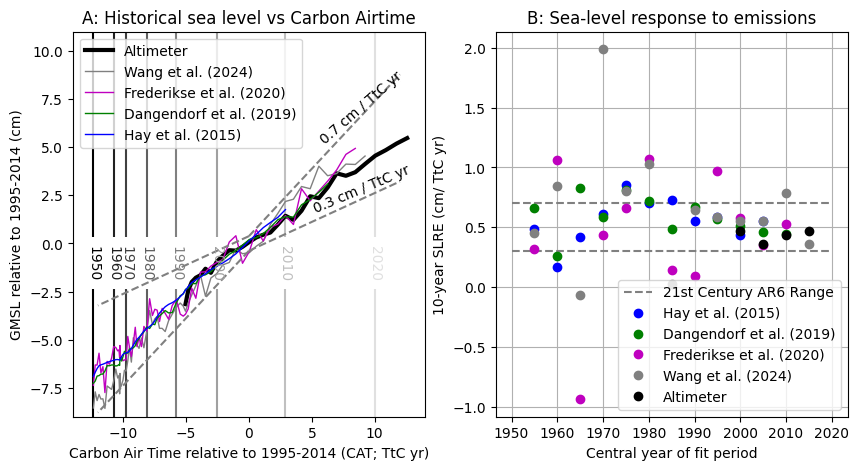

In [31]:
fig, ax = plt.subplots(1,2,figsize = [10,5])

yr1 = 1950
SLRsubset = ['Hay et al.,  2015 (mm)','Dangendorf et al., 2019 (mm)',\
              'Frederikse et al., 2020 (mm)','Wang et al., 2024 (mm)',\
             'Altimeter (mm)']

SLlbl = ['Hay et al. (2015)','Dangendorf et al. (2019)',\
              'Frederikse et al. (2020)','Wang et al. (2024)',\
             'Altimeter']
SLclr = ['b','g','m','gray','k']
widths = [1,1,1,1,3]

CS = ax[0].contour(TotAirTime19952014ref[(df.Year>=yr1) & (df.Year<2024)].values,\
             np.arange(-12,12,1),\
             np.array([df.Year[(df.Year>=yr1) & (df.Year<2024)].values]*\
                      len(np.arange(-12,12,1))),\
             cmap='grey')

ax[0].clabel(CS, CS.levels)

for cx in range(4,-1,-1):
  ax[0].plot(\
           TotAirTime19952014ref[df.Year>=yr1],\
        (df.loc[df.Year>=yr1,SLRsubset[cx]] -\
        df.loc[df.Year>=yr1,'Historical land water (mm)']).values/10,\
           label=SLlbl[cx],linewidth=widths[cx],color=SLclr[cx])

ax[0].legend()
#ax[0].grid()

zoten=np.array([0,12]);

ax[0].plot(zoten,sig_aTG+(zoten*CATSLratio_high),'--',color='grey')
ax[0].plot(-zoten,-sig_aTG-(zoten*CATSLratio_high),'--',color='grey')
ax[0].text(5.5, 5.2, str(CATSLratio_high)+' cm / TtC yr', rotation=np.tan(0.62)*180/np.pi)

ax[0].plot(zoten,-sig_aTG+(zoten*CATSLratio_low),'--',color='grey')
ax[0].plot(-zoten,sig_aTG-(zoten*CATSLratio_low),'--',color='grey')
ax[0].text(5, 1.6, str(CATSLratio_low)+' cm / TtC yr', rotation=np.tan(0.38)*180/np.pi)
ax[0].axis([-14,14,-9,11])
ax[0].set_xlabel('Carbon Air Time relative to 1995-2014 (CAT; TtC yr)')
ax[0].set_ylabel('GMSL relative to 1995-2014 (cm)')
##
ax[1].plot([1950,2020],\
                 [CATSLratio_low,CATSLratio_low],
                 '--',color='grey',label='21st Century AR6 Range')
ax[1].plot([1950,2020],\
                 [CATSLratio_high,CATSLratio_high],
                 '--',color='grey')
for cx in range(0,len(SLROBSset)):
  ax[1].plot(1905+5*np.arange(0,decades),fitObsDEC[cx,:],\
           'o',color=SLclr[cx],label=SLlbl[cx])
ax[1].legend()
ax[1].grid()
ax[1].set_ylabel('10-year SLRE (cm/ TtC yr)')
ax[1].set_xlabel('Central year of fit period')
#ax[1].axis([1950,2020,-1,2.5])
ax[0].set_title('A: Historical sea level vs Carbon Airtime')
ax[1].set_title('B: Sea-level response to emissions')


(array([[ 187.76823705],
        [ 253.9925541 ],
        [ 448.47121713],
        [ 964.11264991],
        [1208.20590744]]),
 np.float64(1.0125084859282594),
 np.int64(2682))

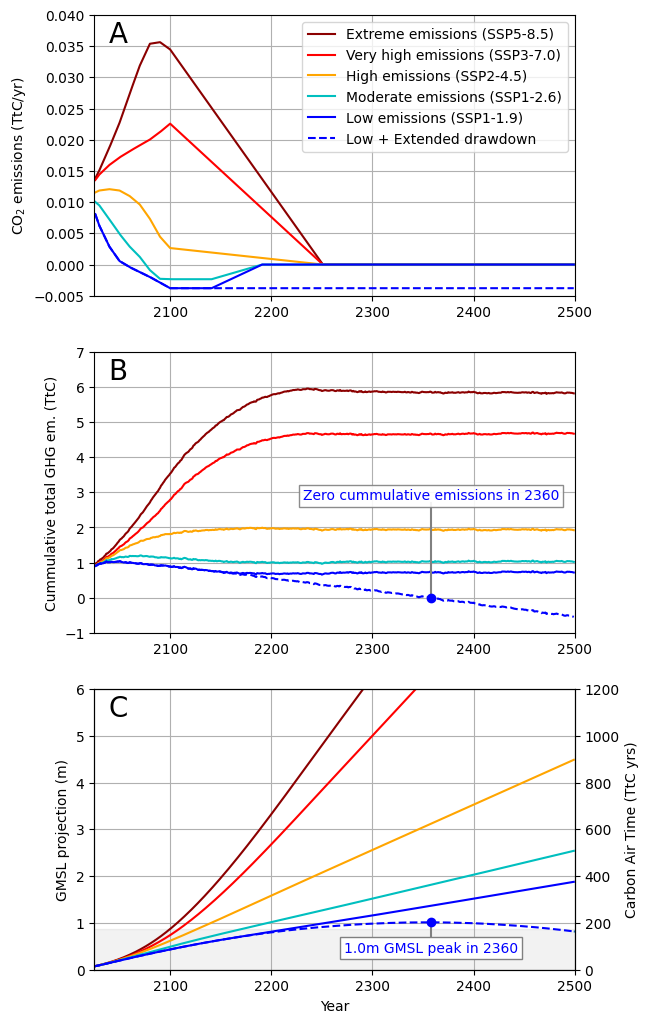

In [32]:
# Post 2100 GMSL
CATSLratio = 0.5
CATSLratio_low = 0.30
CATSLratio_high = 0.70
negem='CO2only'
MaxSLrange = CATSLratio*1.75


yr2=2024
# Slope is
safeslope = 0.01*b
MaxAirtime = 100/CATSLratio
yrEx1=yrEND
yrEx1p1=2140
yrEx1p2=2190
yrEx2=2250
yrEx3=2500
YRSpst2100 = np.arange(0,yrEx3-yrEx1,1)

# For SSP1-19-low scenario
EMExfactor_neg = np.concatenate((\
              ((1+0*(YRSpst2100[YRSpst2100<(yrEx1p1-yrEx1)]))),\
              ((1-((YRSpst2100[(YRSpst2100>=(yrEx1p1-yrEx1)) & \
               (YRSpst2100<(yrEx1p2-yrEx1))]-(yrEx1p1-yrEx1))\
             /(yrEx1p2-yrEx1p1)))),\
              (0*YRSpst2100[YRSpst2100>=(yrEx1p2-yrEx1)])))

EMS = np.zeros(3)

fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize = [6.2,12.4])
SLmax = np.zeros((len(SSPs),1))

for ssp in range(len(SSPs)-1,-1,-1):
    #Calibrate so total Airtime is same at 2100
    TotalAirtime = \
     TotAirTime19952014ref[df.Year==yr2-1].values + \
     np.cumsum(df.loc[(df.Year>=yr2) & (df.Year<yrEx3),SSPs[ssp]+' cumilative CO_2 emissions (TtC)']+\
      df.loc[(df.Year>=yr2) & (df.Year<yrEx3),SSPs[ssp]+' non-CO_2 forcing (TtC; CO_2 equiv.)']\
      ).values
    TotalAirtime_CO2 = \
     CO2AirTime19952014ref[df.Year==yr2-1] + \
     np.cumsum(df.loc[(df.Year>=yr2) & (df.Year<yrEx3),SSPs[ssp]+' cumilative CO_2 emissions (TtC)']\
      ).values

    CumEm_C02 = np.diff(TotalAirtime_CO2)

    Em = np.diff(CumEm_C02)

    ax1.plot(df.loc[(df.Year>yr2+1) & (df.Year<yrEx3+1),'Year'],\
        Em,color=clr[ssp],label =lbl[ssp])

    ax2.plot(df.loc[(df.Year>yr2+1) & (df.Year<yrEx3+1),'Year'],\
        df.loc[(df.Year>yr2+1) & (df.Year<yrEx3+1),SSPs[ssp]+\
               ' cumilative CO_2 emissions (TtC)']+\
        df.loc[(df.Year>yr2+1) & (df.Year<yrEx3+1),SSPs[ssp]+\
               ' non-CO_2 forcing (TtC; CO_2 equiv.)']\
        ,color=clr[ssp],label =lbl[ssp])

    ax3.plot(df.loc[(df.Year>yr2-1) & (df.Year<yrEx3+1),'Year'],\
        TotalAirtime*CATSLratio/100,color=clr[ssp])

    SLmax[ssp] = TotalAirtime[-1]*CATSLratio

    if SSPs[ssp]=='SSP119':
      if negem=='CO2only':
        Em[(2100-yr2):(yrEx3-yr2)] =  Em[2100-yr2]
        #CumEm = np.diff(TotalAirtime)
        CumEmExCO2 = CumEm_C02
        CumEmExCO2[(yrEx1p1-yr2):] = CumEmExCO2[(yrEx1p1-yr2-1)]+\
        np.cumsum(Em[(yrEx1p1-yr2-1):])
        CumEmEx = CumEmExCO2+df.loc[(df.Year>yr2) & (df.Year<yrEx3+1),SSPs[ssp]+\
               ' non-CO_2 forcing (TtC; CO_2 equiv.)']
        AirTimeEx = TotalAirtime
        AirTimeEx[(yrEx1p1-yr2):] = AirTimeEx[(yrEx1p1-yr2-1)]+\
                np.cumsum(CumEmEx[(yrEx1p1-yr2-1):])
        POSTPROJ = AirTimeEx[-1]+\
        np.cumsum(CumEmExCO2[-1] +\
                  np.cumsum(Em[-1]+0*np.arange(0,500)))+\
        np.cumsum(df.loc[df.Year==2499,SSPs[ssp]+\
        ' non-CO_2 forcing (TtC; CO_2 equiv.)'].values+\
        0*np.arange(0,500))

        ax3.plot(np.arange(2500,3000),POSTPROJ*CATSLratio/100)
      else:
        Em[(2100-yr2):(yrEx3-yr2)] =  Em[2100-yr2]
        CumEm = np.diff(TotalAirtime)
        CumEmRatio = CumEm[yrEx1p1-yr2]/CumEm_C02[yrEx1p1-yr2];
        CumEmEx = CumEm
        CumEmEx[(yrEx1p1-yr2):] = CumEmEx[(yrEx1p1-yr2-1)]+\
        np.cumsum(Em[(yrEx1p1-yr2-1):])*CumEmRatio
        AirTimeEx = TotalAirtime
        AirTimeEx[(yrEx1p1-yr2):] = AirTimeEx[(yrEx1p1-yr2-1)]+\
        np.cumsum(CumEmEx[(yrEx1p1-yr2-1):])
      ax1.plot(df.loc[(df.Year>yr2+1) & (df.Year<yrEx3+1),'Year'],\
        Em,'--',color=clr[ssp],label='Low + Extended drawdown')
      ax2.plot(df.loc[(df.Year>yr2) & (df.Year<yrEx3+1),'Year'],\
        CumEmEx,'--',color=clr[ssp])
      ax3.plot(df.loc[(df.Year>yr2-1) & (df.Year<yrEx3+1),'Year'],
        AirTimeEx*CATSLratio/100,'--',color=clr[ssp])

ax1.grid()
ax2.grid()
ax3.grid()

ax1.set_ylabel('CO$_2$ emissions (TtC/yr)')
ax2.set_ylabel('Cummulative total GHG em. (TtC)')
ax3.set_ylabel('GMSL projection (m)')
ax3.set_xlabel('Year')
ax1.legend()

ax1.axis([2025,2500,-0.005,0.04])
ax2.axis([2025,2500,-1,7])

[maxSL,indx] = [\
                np.max(CATSLratio*AirTimeEx/100),\
                np.argmax(CATSLratio*AirTimeEx/100)\
                ]

ax3.fill_between([2000,2500],[MaxSLrange,MaxSLrange],[0,0],\
                 color='grey',alpha=0.1)

[zerondx] = [\
                np.where(POSTPROJ<0)[0][0]\
                ]

zrlbl = [indx+yr2,2.7]
ax2.plot([zrlbl[0],zrlbl[0]],[0,zrlbl[1]],color='grey')
ax2.plot(zrlbl[0],0,'o',color=clr[0])
ax2.text(zrlbl[0],zrlbl[1],\
         'Zero cummulative emissions in '+str(np.round(zrlbl[0],-1)),\
         color=clr[0],\
         horizontalalignment='center',\
         verticalalignment='bottom',\
         bbox={'edgecolor': 'grey','facecolor':'w', 'alpha': 0.9, 'pad': 3})

ax1.text(0.03, 0.88, "A",
        transform=ax1.transAxes,  # Use axes-relative coordinates
        horizontalalignment='left',
        verticalalignment='bottom',
        fontsize=20,
        color='k')

ax2.text(0.03, 0.88, "B",
        transform=ax2.transAxes,  # Use axes-relative coordinates
        horizontalalignment='left',
        verticalalignment='bottom',
        fontsize=20,
        color='k')

ax3.text(0.03, 0.88, "C",
        transform=ax3.transAxes,  # Use axes-relative coordinates
        horizontalalignment='left',
        verticalalignment='bottom',
        fontsize=20,
        color='k')

SLax = [2025,2500,0,6]
ax3.axis(SLax)
ax3.set_yticks([0,1,2,3,4,5,6])

ax4 = ax3.twinx()
ax4.set_ylabel('Carbon Air Time (TtC yrs)')

pklbl = [zrlbl[0],100*(maxSL*2-0.8)]
ax4.plot([zrlbl[0],pklbl[0]],[100*(maxSL/CATSLratio),pklbl[1]],color='grey')
ax4.plot(zrlbl[0],100*(maxSL/CATSLratio),'o',color=clr[0])
ax4.text(pklbl[0],pklbl[1],\
         str(round(maxSL,ndigits=1))+'m GMSL peak in '+str(np.round(zrlbl[0],-1)),\
         color=clr[0],\
         horizontalalignment='center',\
         verticalalignment='top',\
         bbox={'edgecolor': 'grey','facecolor':'w', 'pad': 3})

ax4.axis([SLax[0],SLax[1],100*SLax[2]/CATSLratio,100*SLax[3]/CATSLratio])

ax4.set_yticks(100*np.arange(0,7,1)/CATSLratio)
SLmax,maxSL,zerondx+2500



(np.float64(1900.0), np.float64(2023.0), np.float64(-20.0), np.float64(11.0))

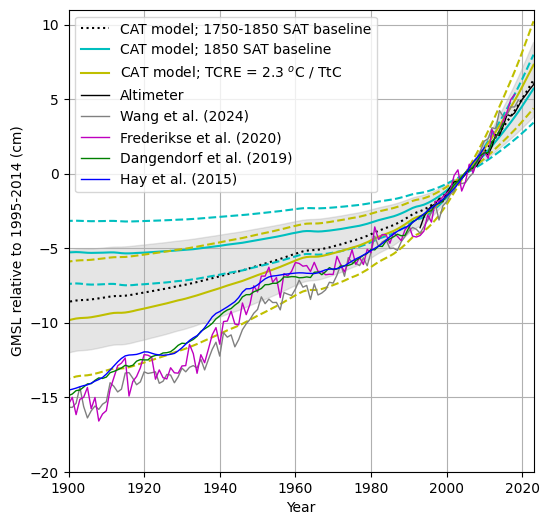

In [34]:
yr1=1750

plt.fill_between(df.Year[df.Year>=yr1],\
         0.3*(CO2AirTime19952014ref+\
          nonCO2AirTime19952014ref)[df.Year>=yr1],\
         0.7*(CO2AirTime19952014ref+\
          nonCO2AirTime19952014ref)[df.Year>=yr1],\
           color='grey',alpha=0.2)
plt.plot(df.Year[df.Year>=yr1],\
         0.5*(CO2AirTime19952014ref+\
          nonCO2AirTime19952014ref)[df.Year>=yr1],\
           'k:',label='CAT model; 1750-1850 SAT baseline')

plt.plot(df.Year[df.Year>=yr1],\
         0.5*(CO2AirTime19952014ref+\
          nonCO2AirTime19952014ref_1800base)[df.Year>=yr1],\
           color='c',label='CAT model; 1850 SAT baseline')
plt.plot(df.Year[df.Year>=yr1],\
         0.7*(CO2AirTime19952014ref+\
          nonCO2AirTime19952014ref_1800base)[df.Year>=yr1],'--',\
           color='c')
plt.plot(df.Year[df.Year>=yr1],\
         0.3*(CO2AirTime19952014ref+\
          nonCO2AirTime19952014ref_1800base)[df.Year>=yr1],'--',\
           color='c')

plt.plot(df.Year[df.Year>=yr1],\
         0.5*(CO2AirTime19952014ref+\
          (2.3/1.65)*nonCO2AirTime19952014ref)[df.Year>=yr1],\
           color='y',label='CAT model; TCRE = 2.3 $^o$C / TtC')
plt.plot(df.Year[df.Year>=yr1],\
         0.7*(CO2AirTime19952014ref+\
          (2.3/1.65)*nonCO2AirTime19952014ref)[df.Year>=yr1],'--',\
           color='y')
plt.plot(df.Year[df.Year>=yr1],\
         0.3*(CO2AirTime19952014ref+\
          (2.3/1.65)*nonCO2AirTime19952014ref)[df.Year>=yr1],'--',\
           color='y')

for cx in range(4,-1,-1):
  plt.plot(\
           df.Year[df.Year>=yr1],\
        (df.loc[df.Year>=yr1,SLRsubset[cx]] -\
        np.isfinite(df.loc[df.Year>=yr1,'Historical land water (mm)'])).values/10,\
           linewidth=1,color=SLclr[cx],label=SLlbl[cx])

plt.legend()
plt.grid()
plt.xlabel('Year')
plt.ylabel('GMSL relative to 1995-2014 (cm)')
plt.axis([1900,2023,-20,11])